## [TECHNICAL NOTEBOOK]Project:Inflation, Forecasting & Strategic Risk Corridor

**Unit:** Simulated Duty to the Monetary Policy Committee(MPC)

**Lead Scientist:** Stephen Munene

**Focus:** Time Series Modelling (ARIMA) & Predictive Probability

### 1.Executive Context & Objective

**What we are trying to do:** Move from past inflation to predicting whats likely to happen next. In short we are conducting a predictive intelligence.

**Target:**
To forecast Kenyas inflation for the next 5 Fiscal Years (2025-2029).

**Framework:** We utilize an ARIMA(1,1,1) model, which is a statistical model that learns from past trends and patterns (Auto-Regression).It looks at how inflation has behaved before including how long the effects of economic shocks tend to last, also called the fade out effect (Moving Avarages).

**Risk Management:** 

We create a "risk corridor," which is a range showing where inflation is most likely to fall. These range helps decision-makers understand both the  expect  outcome and the level of uncertainity. These will be based on 95% Confidence Interval to visualize the boundary of mathematical Probability.


### 2.Calling in the nessecary guns

We rely on `statsmodels` on the econometrics heavy lifting.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import warnings

# Suppressing unnessecary warnings for a cleaner report
warnings.filterwarnings('ignore')

# Good professional Financial styling
plt.style.use('fivethirtyeight')
plt.rcParams['figure.figsize']=(14,7)#For all plots globally

# Loading the clean dataset from the descriptive analysis
df = pd.read_csv('kenya_inflation_data.csv')
series = df.sort_values('year').set_index('year')['inflation']

### 3. The Predictive Engine: ARIMA(1,1,1)

We use the simple and reliable model, ARIMA(1,1,1) , which works well for yearly economic data like inflation.

**What the numbers mean:**

- **p = 1 (Past Influence):** This years inflation is affected by last years inflation.In simple terms trends tend to continue.
- **d = 1 (Stability):** We look at the change of one yaer to the next instead of raw values.Makes the data more stable and easier to model.
- **q = 1 (Shock effects):** The models considers that major events (Economic shocks,crises), don't dissappear immediately, their effects fade over time.

In [3]:
# Intitalize and Fit the model
# Order (1,1,1) is the 'Sweetspot' for a small macro-economic dataset of 65 rows

model = ARIMA(series, order=(1,1,1))
model_fit = model.fit()

# Generate the 5-year forecast (2025-2029)

forecast_steps = 5
forecast_res = model_fit.get_forecast(steps=forecast_steps)
forecast_df = forecast_res.summary_frame()

# Re_indexing for the timeline
forecast_df.index = np.arange(2025, 2025 + forecast_steps)

print("--- MODEL DIAGNOSTICS: SUMMARY ---")
print(model_fit.summary().tables[1])

--- MODEL DIAGNOSTICS: SUMMARY ---
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5617      0.193      2.907      0.004       0.183       0.940
ma.L1         -0.9155      0.088    -10.352      0.000      -1.089      -0.742
sigma2        41.0216      4.726      8.680      0.000      31.759      50.285


**What the model is showing:**

**1.Strong link to the past(`AR term = 0.56`):**
Inflation these year is moderate influenced by last year.
These means inflation has `momentum` it doesn't jump randomly, it tends to follow its recent path.

**2. Shock effects are strong but fade (`MA term = -92`):**
Past economic shocks or crisis have a **big immediate impact** but the also **fade out quickly** over time.

The large negative value suggests:
- When a shock hits, inflation may swing.
- But the system corrects itself relatively fast.

**3. The Model is statistically solid (`very low p-values`):**

All key components (AR, MA, variance) are highly significant:
- p-values are close to 0.
- This means the patterns the models found are **real** not just **random noise**.

**4. Volatility is not small (`sigma² ≈ 41`):**

Inflation has **noticeable fluctuations.**

Even with a good model there is uncertainity , so forecasts won't be perfectly smooth.


**One sentence insight:**

`Inflation shows moderate persistence, reacts strongly to shocks, but tends to stabilize overtime, though with noticeable volatility that requires close monitoring.`


### 4. Visualizing the "Risk Corridor"

AS a scientist, I never provide a one point estimate or a single forecast number, instead I show a range where the inflation is most likely to fall.

**Why These Matters:**
These matters because a single estimate can be misleading. The range shows expected outcome and the uncertainity around it.

**How to use it:**
If inflation starts moving towards the edges of these range (the "pink cloud"), it serves as an early warning. These may signal the need for policy action.


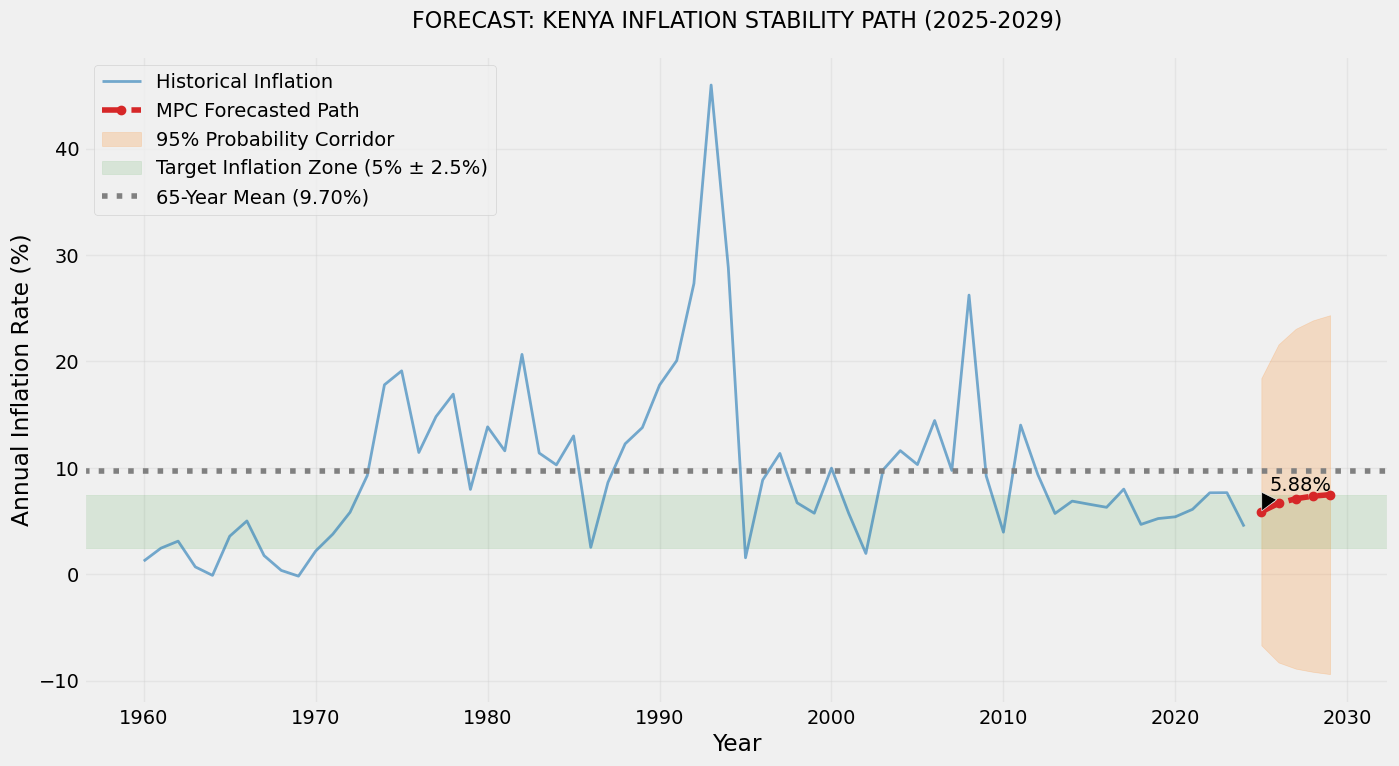

In [6]:
plt.figure(figsize=(15, 8))

# 1. Historical Baseline (1960-2024)
plt.plot(series.index, series.values, label='Historical Inflation', color='#1f77b4', linewidth=2, alpha=0.6)

# 2. Predicted Path (2025-2029)
plt.plot(forecast_df.index, forecast_df['mean'], label='MPC Forecasted Path', color='#d62728', linestyle='--', marker='o')

# 3. The Risk Corridor (95% Confidence Interval)
plt.fill_between(forecast_df.index, 
                 forecast_df['mean_ci_lower'], 
                 forecast_df['mean_ci_upper'], 
                 color='#ff7f0e', alpha=0.2, label='95% Probability Corridor')

# 4. Institutional Policy Markers
plt.axhspan(2.5, 7.5, color='green', alpha=0.1, label='Target Inflation Zone (5% ± 2.5%)')
plt.axhline(series.mean(), color='grey', linestyle=':', label=f'65-Year Mean ({series.mean():.2f}%)')

# Annotating the Forecasted Year 2025
plt.annotate(f"{forecast_df['mean'].iloc[0]:.2f}%", 
             xy=(2025, forecast_df['mean'].iloc[0]), 
             xytext=(2025.5, forecast_df['mean'].iloc[0]+2),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.title("FORECAST: KENYA INFLATION STABILITY PATH (2025-2029)", fontsize=16, pad=20)
plt.ylabel("Annual Inflation Rate (%)")
plt.xlabel("Year")
plt.legend(loc='upper left', frameon=True)
plt.grid(True, alpha=0.3)

plt.show();

**What the chart shows:**

The blue line represents the historical inflation, while the shaded area "risk-corridor" shows the range where future inflation is most likely to fall.The red line , the central path, shows the model's forecast.

**MPC Forecast Path:**

The forecast path trends toward moderate, stable inflation levels, settling around the mid-range of the corridor. This suggests no extreme upward or downward pressure in the near term.

**Mean Reversion:**
The model indicates that inflation naturally moves back toward its long-term average after periods of volatility.
Following past spikes, the current trajectory shows inflation returning and stabilizing within normal levels.

**Position Relative to Target:**
The current level (around 5.9%) sits within the target range and below the upper bound.
The forecast path remains within this band, indicating that inflation is expected to stay aligned with policy objectives.

**Risk Signal (Corridor Interpretation):**

- Movement toward the upper edge → rising inflation risk.
- Movement toward the lower edge → weakening demand.
- Current position → stable, low-risk zone.

**Key Takeaway**

The forecast shows inflation reverting to stable levels within the target range, with no immediate pressure on policy, but with risks still present at the corridor boundaries.



### 5. Strategic Insights for the Top Decision-maker

**Mean Reversion:**

Inflation demonstrates a consistent tendency to return to stable levels after periods of volatility.
The current trajectory confirms that the system is already within a stable range, rather than moving back from extreme levels.

**MPC Forecast Path:**

The projected path shows inflation remaining within moderate levels, without drifting toward extreme highs or lows.
This suggests a balanced outlook, with no immediate signs of overheating or sharp decline.

**Position Relative to Target:**

Inflation is currently within the target band and below the upper threshold.
The forecast path remains aligned with this range, indicating that price stability is being maintained.

**Risk Assessment:**

The risk corridor highlights that while the central expectation is stable inflation, there remains upside risk from external shocks.
However, the current position within the corridor suggests low immediate pressure on policy.

**Policy Implication:**

The present conditions support a neutral policy stance.
Policy should remain steady, with flexibility to respond if inflation begins to move toward the corridor boundaries.

**Executive Takeaway:**

Inflation is stable, within target, and expected to remain so. The priority is to maintain this stability while staying alert to potential external risks.

### 6. Model Limitations 

Even a strong model has limits. The following factors should be considered when interpreting the results from the Inflation Risk Intelligence System (IRIS):

**1. Sensitivity to Extreme Events:**
The 1993 inflation spike (45.9%) is unusually high compared to normal levels. Because the model uses past volatility to estimate future risk, this event makes the risk corridor wider than usual.

What this means:

The model may appear overly cautious by preparing for extreme scenarios
Or it may treat such events as rare and fail to fully anticipate similar shocks

**2. Blind Spot to External Shocks:**
The model only uses past inflation data. It does not include external factors.

What it misses:

Changes in global oil prices
Weather shocks affecting food supply
International interest rate movements

Key takeaway:
The model captures inflation trends, but it cannot predict sudden external shocks.

**3. Limited Data Size:**
The model is based on about 65 annual data points.

What this means:

It is sufficient for long-term trends
But it lacks detailed, short-term movements

Improvement path:
Future work should use monthly data to capture seasonal and short-term changes.

**4. Assumes Stable Relationships:**
The model assumes that inflation behaves in a relatively consistent way over time.

Reality:
Inflation can change suddenly, moving between low and high periods.

Implication:
The model may not fully capture these sudden shifts.

**Bottom Line**

The model is useful for understanding trends and risks, but it should be used alongside economic judgment, especially when dealing with unexpected events.

### 7. Final Recommendation (Lead Scientist’s Verdict)

The ARIMA Model should be used as a guiding framework, not a precise prediction tool.

**Action Zone (Model Alignment):**

If inflation for 2025 remains within the projected corridor and close to current levels (around 5%–7%), the model is performing as expected.
This confirms that inflation is stable and policy is well-calibrated.

**Caution Zone (Early Warning):**

If inflation begins to trend toward the upper boundary of the corridor, this signals rising pressure.
At this stage, the MPC should increase monitoring and prepare for possible intervention.

**Alert Zone (Policy Trigger):**

If inflation moves significantly beyond the corridor (for example, approaching or exceeding 10%), this indicates that underlying conditions have changed.

**Required response:**

- Reassess the model assumptions
- Shift from baseline forecasting to a stress-test scenario
- Investigate external drivers (food, fuel, exchange rate)
- Final Verdict

The model confirms a stable inflation environment, but its true value lies in acting as an early warning system. Policy should remain steady, while staying ready to respond if inflation moves outside expected bounds.

<div style="padding: 15px; border: 1px solid #e1e4e8; border-radius: 6px; background-color: #f6f8fa;">
    <h4 style="margin-top: 0; color: #d73a49;">⚠️ Non-Affiliation Disclaimer</h4>
    <p style="font-size: 0.9em; color: #586069;">
        This notebook is an <strong>independent technical exercise</strong> and is not 
        commissioned by, nor affiliated with, the Central Bank of Kenya (CBK). 
        The "Lead Scientist" persona is used strictly for simulated business context. 
        <strong>No official endorsement is implied.</strong>
    </p>
</div>